# Experiment Grid & Stability Analysis

This notebook runs a comprehensive experiment grid comparing:
- **4 representations**: BlocShares, RawPartyShares, PCA(5), NMF(5)
- **3 distance metrics**: Euclidean, Cosine, Jensen-Shannon
- **4 spatial algorithms**: SimulatedAnnealing, Agglomerative, Louvain, K-means baseline
- **Multiple K values**: 3, 5, 7, 10, 15, 20

Plus **stability analysis** (per-election clustering + ARI/NMI) for top configurations.

All logic uses modular `src/` components.

In [1]:
import sys
sys.path.insert(0, '..')

import json
import logging
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

from src.config import DATA_PROCESSED, BLOC_COLS
from src.data.processing import process_all_elections
from src.data.representations import BlocShares, RawPartyShares, PCARepresentation, NMFRepresentation
from src.data.distance_metrics import EuclideanDistance, CosineDistance, JensenShannonDistance
from src.graph.preprocessing import preprocess_graph
from src.clustering.simulated_annealing import SimulatedAnnealingClusterer
from src.clustering.agglomerative import AgglomerativeSpatialClusterer
from src.clustering.spectral import LouvainSpatialClusterer
from src.clustering.baseline import KMeansBaselineClusterer
from src.clustering.base import CantonAssignment
from src.evaluation.experiment import ExperimentRunner
from src.evaluation.stability import run_stability_analysis
from src.evaluation.metrics import canton_profiles
from src.visualization.charts import plot_experiment_results, plot_stability_heatmap, plot_elbow
from src.visualization.maps import plot_cantons, plot_canton_comparison

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')
DATA_PROCESSED.mkdir(exist_ok=True)
print("Setup complete")

Setup complete


## 1. Load Data & Build Graph

In [2]:
# Load elections
elections = process_all_elections()
print(f"Loaded {len(elections)} elections")

# Build features (BlocShares) for graph preprocessing & weights
bloc_repr = BlocShares(include_std=True)
bloc_features = bloc_repr.fit_transform(elections)
bloc_feature_cols = bloc_repr.feature_names

# Load adjacency graph
with open(DATA_PROCESSED / 'adjacency_graph.json', 'r', encoding='utf-8') as f:
    adj_list = json.load(f)

G_raw = nx.Graph()
for node, neighbors in adj_list.items():
    G_raw.add_node(node)
    for n in neighbors:
        G_raw.add_edge(node, n)

# Filter to feature municipalities
feat_munis = set(bloc_features['municipality'])
G = G_raw.subgraph(feat_munis & set(G_raw.nodes())).copy()

# Preprocess graph
feat_indexed = bloc_features.set_index('municipality')
G_aug = preprocess_graph(G, feat_indexed, bloc_feature_cols)
print(f"Graph: {G_aug.number_of_nodes()} nodes, {G_aug.number_of_edges()} edges, connected={nx.is_connected(G_aug)}")

# Weights
weights = dict(zip(bloc_features['municipality'], bloc_features['avg_votes']))
print(f"Total voters: {sum(weights.values()):,.0f}")

Loaded 5 elections
Graph: 229 nodes, 2178 edges, connected=True
Total voters: 3,924,078


## 2. Define Experiment Grid

In [3]:
# Representations
representations = [
    BlocShares(include_std=True),
    RawPartyShares(),
    PCARepresentation(n_components=5),
    NMFRepresentation(n_components=5),
]

# Distance metrics
distance_metrics = [
    EuclideanDistance(),
    CosineDistance(),
    JensenShannonDistance(),
]

# Clustering algorithms
clusterers = [
    SimulatedAnnealingClusterer(max_iterations=5_000, random_seed=42),
    AgglomerativeSpatialClusterer(linkage='average'),
    LouvainSpatialClusterer(random_seed=42),
    KMeansBaselineClusterer(random_state=42),
]

# K values (spec: 3, 5, 7, 10, 15, 20)
k_values = [3, 5, 7, 10, 15, 20]

print(f"Representations: {[r.name for r in representations]}")
print(f"Distance metrics: {[d.name for d in distance_metrics]}")
print(f"Clusterers: {[c.name for c in clusterers]}")
print(f"K values: {k_values}")

Representations: ['bloc_shares', 'raw_party_shares', 'pca_5', 'nmf_5']
Distance metrics: ['euclidean', 'cosine', 'jensen_shannon']
Clusterers: ['simulated_annealing', 'agglomerative_average', 'louvain', 'kmeans_baseline']
K values: [3, 5, 7, 10, 15, 20]


## 3. Run Experiment Grid

In [4]:
runner = ExperimentRunner(
    representations=representations,
    distance_metrics=distance_metrics,
    clusterers=clusterers,
    k_values=k_values,
    elections=elections,
    graph=G_aug,
    weights=weights,
)

configs = runner.build_configs()
print(f"Total valid configurations: {len(configs)}")
print(f"\nSample configs:")
for c in configs[:5]:
    print(f"  {c.label}")

Total valid configurations: 264

Sample configs:
  bloc_shares__euclidean__simulated_annealing__k3
  bloc_shares__euclidean__simulated_annealing__k5
  bloc_shares__euclidean__simulated_annealing__k7
  bloc_shares__euclidean__simulated_annealing__k10
  bloc_shares__euclidean__simulated_annealing__k15


In [5]:
# Run all experiments (this may take a while)
save_dir = DATA_PROCESSED / 'experiments'
results_df = runner.run_all(save_dir=save_dir)

print(f"\nCompleted {len(results_df)} experiments")
print(f"Errors: {results_df['error'].notna().sum()}")
print(f"\nResults saved to {save_dir}")

INFO: Running 264 experiments


INFO: [1/264] bloc_shares__euclidean__simulated_annealing__k3


INFO: [2/264] bloc_shares__euclidean__simulated_annealing__k5


INFO: [3/264] bloc_shares__euclidean__simulated_annealing__k7


INFO: [4/264] bloc_shares__euclidean__simulated_annealing__k10


...

INFO: [261/264] nmf_5__jensen_shannon__kmeans_baseline__k7


INFO: [262/264] nmf_5__jensen_shannon__kmeans_baseline__k10


INFO: [263/264] nmf_5__jensen_shannon__kmeans_baseline__k15


INFO: [264/264] nmf_5__jensen_shannon__kmeans_baseline__k20



Completed 264 experiments
Errors: 0

Results saved to /Users/adirelmakais/Desktop/israel-cantons-project/data/processed/experiments


## 4. Analyse Results

In [6]:
# Filter successful runs
ok = results_df[results_df['error'].isna()].copy()
print(f"Successful runs: {len(ok)} / {len(results_df)}")

# Show top results by silhouette score
if 'silhouette' in ok.columns:
    top = ok.nlargest(15, 'silhouette')[['repr', 'metric', 'algo', 'k_target', 'k_actual', 'silhouette', 'pop_cv', 'wcss', 'n_disconnected', 'elapsed_s']]
    print("\nTop 15 by Silhouette Score:")
    print(top.to_string(index=False))

Successful runs: 264 / 264

Top 15 by Silhouette Score:
            repr         metric                  algo  k_target  k_actual  silhouette   pop_cv         wcss  n_disconnected  elapsed_s
     bloc_shares      euclidean agglomerative_average         3         3    0.904622 1.130458 1.245256e+11               0       0.15
     bloc_shares      euclidean       kmeans_baseline         3         3    0.857999 0.483840 2.996759e+10               3       0.04
     bloc_shares         cosine       kmeans_baseline         3         3    0.857999 0.483840 2.996759e+10               3       0.04
     bloc_shares jensen_shannon       kmeans_baseline         3         3    0.857999 0.483840 2.996759e+10               3       0.04
     bloc_shares      euclidean agglomerative_average         5         5    0.783614 1.503624 9.809042e+10               0       0.20
     bloc_shares      euclidean       kmeans_baseline         5         5    0.662733 0.210550 8.300490e+09               5       0.04

In [7]:
# Compare algorithms (averaged over all representations and metrics)
if 'silhouette' in ok.columns:
    algo_summary = ok.groupby('algo').agg({
        'silhouette': 'mean',
        'pop_cv': 'mean',
        'wcss': 'mean',
        'elapsed_s': 'mean',
    }).round(3)
    print("Algorithm comparison (averaged):")
    print(algo_summary)

Algorithm comparison (averaged):
                       silhouette  pop_cv          wcss  elapsed_s
algo                                                              
agglomerative_average       0.050   2.348  5.043380e+10      0.231
kmeans_baseline             0.484   0.683  1.988306e+09      0.055
louvain                    -0.097   1.154  5.854925e+10      0.348
simulated_annealing        -0.226   0.573  4.994895e+10     26.249


In [8]:
# Compare representations
if 'silhouette' in ok.columns:
    repr_summary = ok.groupby('repr').agg({
        'silhouette': 'mean',
        'pop_cv': 'mean',
        'wcss': 'mean',
    }).round(3)
    print("Representation comparison (averaged):")
    print(repr_summary)

Representation comparison (averaged):
                  silhouette  pop_cv          wcss
repr                                              
bloc_shares           -0.167   1.116  1.475101e+11
nmf_5                  0.137   1.230  1.528820e+02
pca_5                  0.147   1.190  9.163673e+04
raw_party_shares       0.125   1.223  1.087698e+05


## 5. Elbow Plot (K Sensitivity)

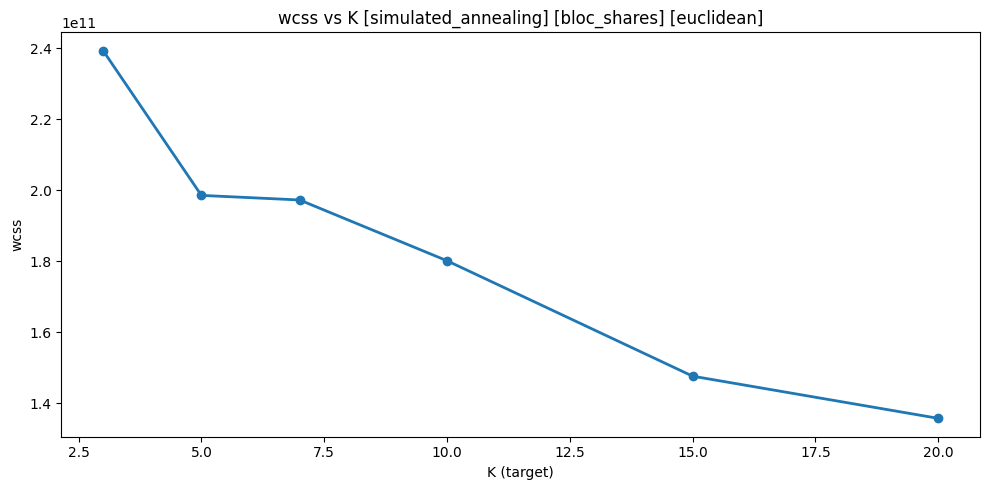

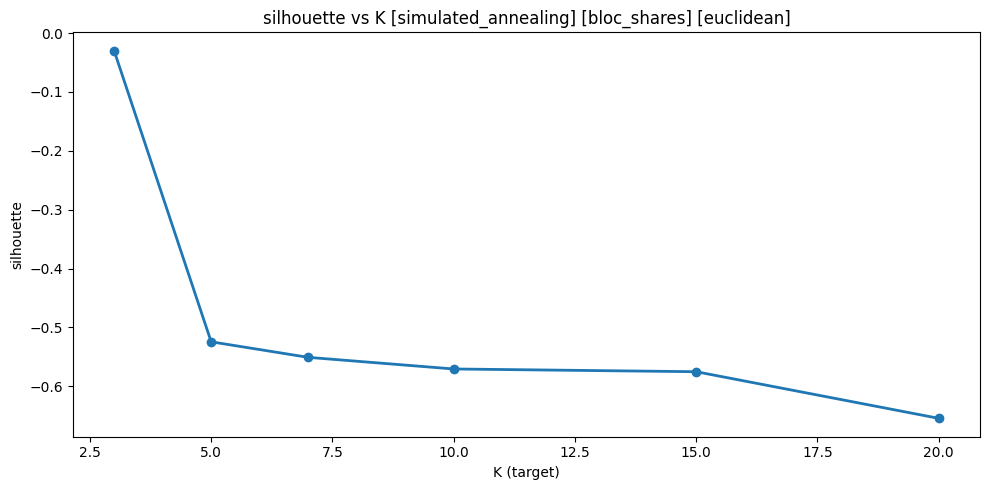

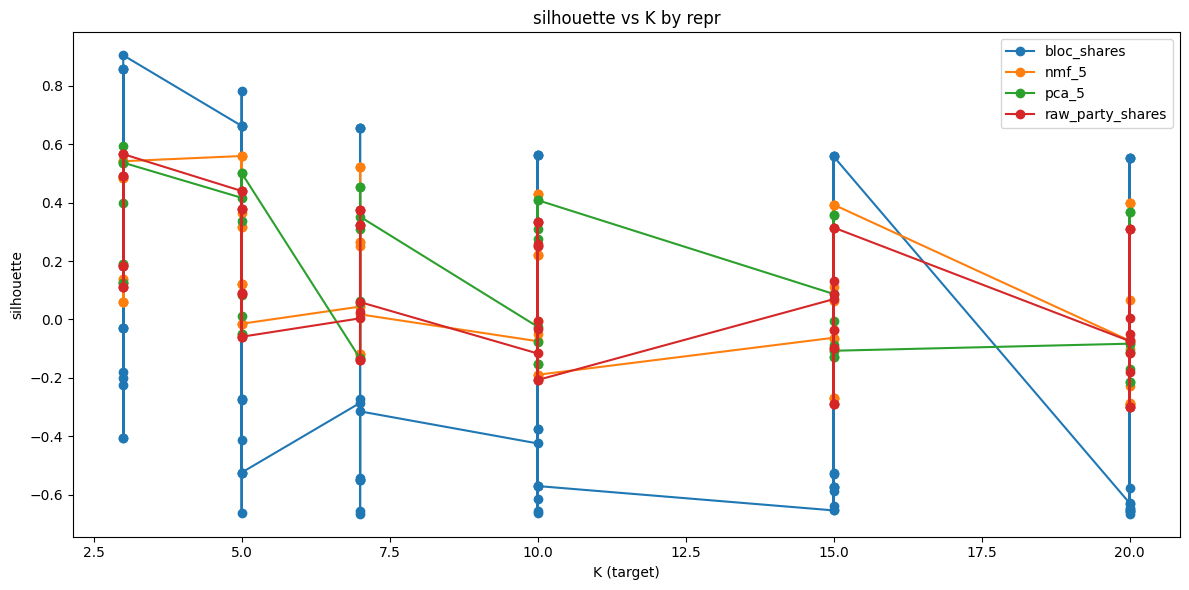

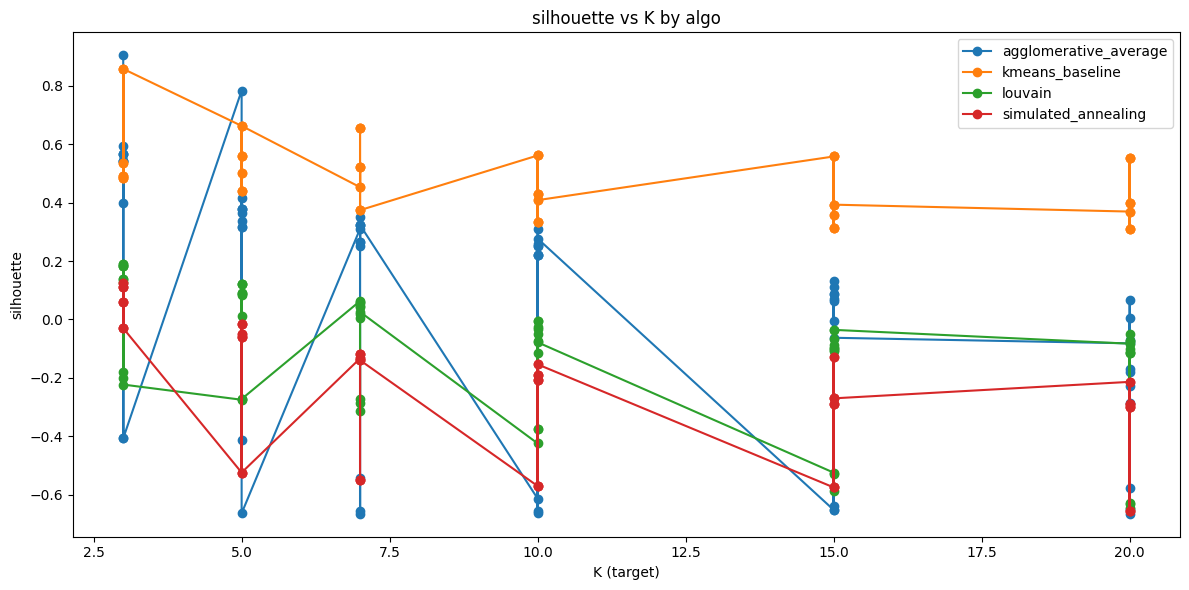

In [9]:
# Elbow plots using src.visualization.charts
if 'silhouette' in ok.columns and len(ok) > 0:
    # WCSS elbow for BlocShares + Euclidean + SA
    fig = plot_elbow(ok, algo='simulated_annealing', repr_name='bloc_shares',
                     metric_name='euclidean', y_metric='wcss')
    plt.show()
    
    # Silhouette elbow for BlocShares + Euclidean + SA
    fig = plot_elbow(ok, algo='simulated_annealing', repr_name='bloc_shares',
                     metric_name='euclidean', y_metric='silhouette')
    plt.show()
    
    # Silhouette vs K by representation (averaged across metrics and algos)
    fig = plot_experiment_results(ok, metric='silhouette', group_by='repr')
    plt.show()
    
    # Silhouette vs K by algorithm
    fig = plot_experiment_results(ok, metric='silhouette', group_by='algo')
    plt.show()

## 6. Stability Analysis

Cluster each election independently and compute pairwise ARI/NMI to measure how stable canton boundaries are across electoral cycles.

In [10]:
# Run stability for multiple configurations
from src.data.distance_metrics import EuclideanDistance

stability_configs = [
    ('BlocShares / Euclidean / SA', BlocShares(include_std=False), EuclideanDistance(), SimulatedAnnealingClusterer(max_iterations=2000, random_seed=42)),
    ('BlocShares / Cosine / Agglom', BlocShares(include_std=False), CosineDistance(), AgglomerativeSpatialClusterer(linkage='average')),
    ('BlocShares / Euclidean / Louvain', BlocShares(include_std=False), EuclideanDistance(), LouvainSpatialClusterer(random_seed=42)),
    ('NMF_5 / Euclidean / SA', NMFRepresentation(n_components=5), EuclideanDistance(), SimulatedAnnealingClusterer(max_iterations=2000, random_seed=42)),
    ('PCA_5 / Euclidean / SA', PCARepresentation(n_components=5), EuclideanDistance(), SimulatedAnnealingClusterer(max_iterations=2000, random_seed=42)),
    ('RawParty / Cosine / SA', RawPartyShares(), CosineDistance(), SimulatedAnnealingClusterer(max_iterations=2000, random_seed=42)),
]

stability_rows = []
all_pairwise = {}

print("Running stability analysis for multiple configurations (K=5)...")
for label, rep, metric, clust in stability_configs:
    print(f"  {label} ...", end=" ", flush=True)
    try:
        per_election, pairwise_df, summary = run_stability_analysis(
            elections=elections, representation=rep,
            distance_metric=metric, clusterer=clust,
            graph=G_aug, k=5,
        )
        print(f"ARI={summary['mean_ari']:.3f}")
        stability_rows.append({
            'config': label,
            'mean_ari': round(summary['mean_ari'], 4),
            'std_ari': round(summary['std_ari'], 4),
            'mean_nmi': round(summary['mean_nmi'], 4),
            'std_nmi': round(summary['std_nmi'], 4),
        })
        all_pairwise[label] = pairwise_df
    except Exception as e:
        print(f"ERROR: {e}")
        stability_rows.append({'config': label, 'mean_ari': None})

stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv(DATA_PROCESSED / 'stability_results.csv', index=False)
print(f"\nSaved stability_results.csv")
print(stability_df.to_string(index=False))

Running stability analysis for multiple configurations (K=5)...
  BlocShares / Euclidean / SA ... 

ARI=0.554
  BlocShares / Cosine / Agglom ... 

ARI=0.954
  BlocShares / Euclidean / Louvain ... 

ARI=1.000
  NMF_5 / Euclidean / SA ... 

ARI=0.616
  PCA_5 / Euclidean / SA ... 

ARI=0.360
  RawParty / Cosine / SA ... 

ARI=0.451

Saved stability_results.csv
                          config  mean_ari  std_ari  mean_nmi  std_nmi
     BlocShares / Euclidean / SA    0.5542   0.1127    0.6015   0.0950
    BlocShares / Cosine / Agglom    0.9540   0.0594    0.9447   0.0714
BlocShares / Euclidean / Louvain    1.0000   0.0000    1.0000   0.0000
          NMF_5 / Euclidean / SA    0.6158   0.2334    0.6816   0.1551
          PCA_5 / Euclidean / SA    0.3602   0.1371    0.4655   0.1233
          RawParty / Cosine / SA    0.4506   0.1203    0.5497   0.0987


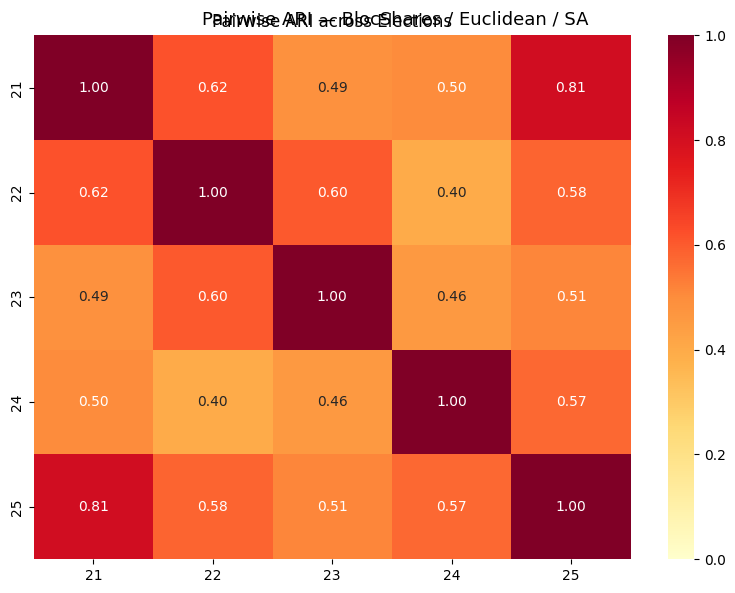

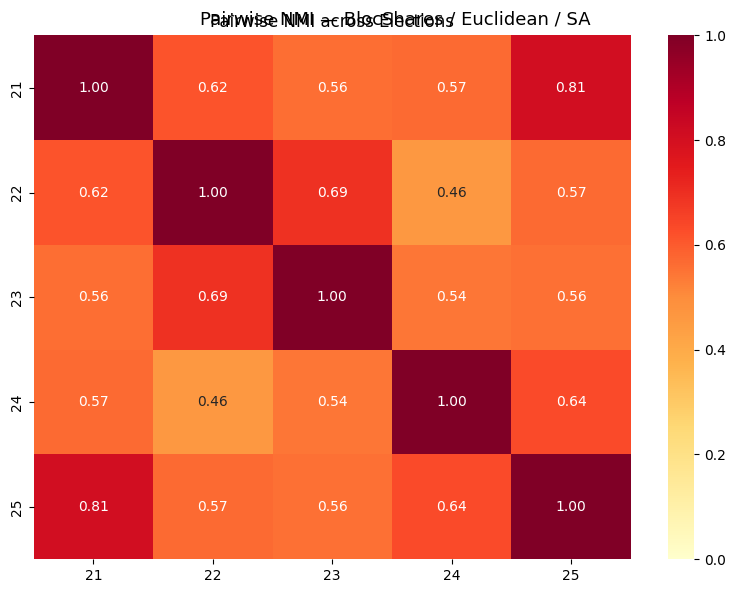

In [11]:
# Stability heatmap using src.visualization.charts
if all_pairwise:
    label0 = list(all_pairwise.keys())[0]
    pw0 = all_pairwise[label0]
    
    fig = plot_stability_heatmap(pw0, metric='ari')
    plt.suptitle(f'Pairwise ARI — {label0}', fontsize=13)
    plt.show()
    
    fig = plot_stability_heatmap(pw0, metric='nmi')
    plt.suptitle(f'Pairwise NMI — {label0}', fontsize=13)
    plt.show()

## 7. Summary

In [12]:
print("=" * 70)
print("EXPERIMENT GRID COMPLETE")
print("=" * 70)
print(f"\nTotal experiments: {len(results_df)}")
print(f"Successful: {len(ok)}")
print(f"Errors: {results_df['error'].notna().sum()}")

if 'silhouette' in ok.columns and len(ok) > 0:
    # Best overall
    best = ok.loc[ok['silhouette'].idxmax()]
    print(f"\nBest by silhouette (all):")
    print(f"  {best['repr']} + {best['metric']} + {best['algo']} (K={best['k_target']})")
    print(f"  Silhouette: {best['silhouette']:.3f}, Pop CV: {best['pop_cv']:.3f}")
    
    # Best spatial-only (exclude kmeans)
    spatial = ok[ok['algo'] != 'kmeans_baseline']
    if len(spatial) > 0:
        best_sp = spatial.loc[spatial['silhouette'].idxmax()]
        print(f"\nBest spatial (contiguous):")
        print(f"  {best_sp['repr']} + {best_sp['metric']} + {best_sp['algo']} (K={best_sp['k_target']})")
        print(f"  Silhouette: {best_sp['silhouette']:.3f}, Pop CV: {best_sp['pop_cv']:.3f}")
    
    # K accuracy
    k_mismatches = ok[ok['k_target'] != ok['k_actual']]
    print(f"\nK accuracy: {len(ok) - len(k_mismatches)}/{len(ok)} exact ({len(k_mismatches)} mismatches)")
    if len(k_mismatches) > 0:
        for _, row in k_mismatches.iterrows():
            print(f"  {row['repr']}/{row['algo']}/k_target={row['k_target']} -> k_actual={row['k_actual']}")

# Stability summary
if len(stability_df) > 0:
    print(f"\nStability (K=5):")
    for _, row in stability_df.iterrows():
        if row.get('mean_ari') is not None:
            print(f"  {row['config']}: ARI={row['mean_ari']:.3f} +/- {row['std_ari']:.3f}")

print(f"\nResults saved to: {save_dir}")
print("=" * 70)

EXPERIMENT GRID COMPLETE

Total experiments: 264
Successful: 264
Errors: 0

Best by silhouette (all):
  bloc_shares + euclidean + agglomerative_average (K=3)
  Silhouette: 0.905, Pop CV: 1.130

Best spatial (contiguous):
  bloc_shares + euclidean + agglomerative_average (K=3)
  Silhouette: 0.905, Pop CV: 1.130

K accuracy: 258/264 exact (6 mismatches)
  bloc_shares/louvain/k_target=7 -> k_actual=5
  bloc_shares/louvain/k_target=10 -> k_actual=11
  bloc_shares/louvain/k_target=20 -> k_actual=21
  raw_party_shares/louvain/k_target=10 -> k_actual=9
  pca_5/louvain/k_target=20 -> k_actual=19
  pca_5/louvain/k_target=10 -> k_actual=9

Stability (K=5):
  BlocShares / Euclidean / SA: ARI=0.554 +/- 0.113
  BlocShares / Cosine / Agglom: ARI=0.954 +/- 0.059
  BlocShares / Euclidean / Louvain: ARI=1.000 +/- 0.000
  NMF_5 / Euclidean / SA: ARI=0.616 +/- 0.233
  PCA_5 / Euclidean / SA: ARI=0.360 +/- 0.137
  RawParty / Cosine / SA: ARI=0.451 +/- 0.120

Results saved to: /Users/adirelmakais/Desktop/i

## 8. Case Studies

Qualitative analysis of how canton boundaries interact with well-known Israeli geographic and political regions.

In [21]:
# Define key regions for case study analysis
# Load best K=5 assignment
best_k5 = pd.read_csv(DATA_PROCESSED / 'cantons_final.csv')
best_assignment = dict(zip(best_k5['municipality'], best_k5['canton']))

# Canton profiles for best K=5
from src.clustering.base import CantonAssignment
ca = CantonAssignment(best_assignment)
profiles_k5 = canton_profiles(ca, bloc_features, weights)

# Define case study regions
regions = {
    'Greater Tel Aviv (Gush Dan)': [
        'תל אביב -יפו', 'רמת גן', 'גבעתיים', 'בני ברק', 'חולון', 'בת ים',
        'פתח תקווה', 'ראשון לציון', 'הרצליה', 'רעננה', 'כפר סבא', 'נתניה',
        'חולון', 'לוד', 'רמלה', 'נס ציונה', 'רחובות',
    ],
    'Jerusalem Region': [
        'ירושלים', 'מודיעין-מכבים-רעות', 'בית שמש', 'קרית יערים',
    ],
    'Arab Towns (Triangle & North)': [
        'אום אל-פחם', 'טייבה', 'נצרת', 'שפרעם', 'טמרה',
        'באקה אל גרבייה', 'עראבה',
    ],
    'Haifa & Krayot': [
        'חיפה', 'קרית אתא', 'קרית ביאליק', 'קרית ים', 'קרית מוצקין',
        'קרית טבעון', 'עכו', 'כרמיאל',
    ],
    'Southern (Negev)': [
        'באר שבע', 'אשדוד', 'אשקלון', 'דימונה', 'ערד', 'אילת',
        'קרית גת', 'קרית מלאכי',
    ],
}

print("CASE STUDY ANALYSIS — K=5 SA Configuration")
print("(BlocShares + Cosine + Simulated Annealing)")
print("=" * 80)

for region_name, municipalities in regions.items():
    print(f"\n{'─' * 80}")
    print(f"Region: {region_name}")
    print(f"{'─' * 80}")
    
    found = [m for m in municipalities if m in best_assignment]
    not_found = [m for m in municipalities if m not in best_assignment]
    
    if not_found:
        print(f"  (Not in data: {not_found})")
    
    # Group by canton
    canton_groups = {}
    for m in found:
        c = best_assignment[m]
        canton_groups.setdefault(c, []).append(m)
    
    n_cantons = len(canton_groups)
    if n_cantons == 1:
        print(f"  ✓ UNIFIED — All {len(found)} municipalities in Canton {list(canton_groups.keys())[0]}")
    else:
        print(f"  ✗ SPLIT across {n_cantons} cantons:")
    
    for cid, members in sorted(canton_groups.items()):
        profile = profiles_k5[profiles_k5['canton'] == cid]
        dominant = profile['dominant_bloc'].iloc[0] if len(profile) > 0 else '?'
        print(f"    Canton {cid} ({dominant.upper()}, {len(members)} in region): {', '.join(members[:5])}", end='')
        if len(members) > 5:
            print(f" + {len(members)-5} more")
        else:
            print()


CASE STUDY ANALYSIS — K=5 SA Configuration
(BlocShares + Cosine + Simulated Annealing)

────────────────────────────────────────────────────────────────────────────────
Region: Greater Tel Aviv (Gush Dan)
────────────────────────────────────────────────────────────────────────────────
  ✗ SPLIT across 2 cantons:
    Canton 1 (RIGHT, 11 in region): תל אביב -יפו, רמת גן, גבעתיים, בני ברק, חולון + 6 more
    Canton 2 (RIGHT, 6 in region): רעננה, נתניה, לוד, רמלה, נס ציונה + 1 more

────────────────────────────────────────────────────────────────────────────────
Region: Jerusalem Region
────────────────────────────────────────────────────────────────────────────────
  ✗ SPLIT across 3 cantons:
    Canton 0 (RIGHT, 2 in region): ירושלים, בית שמש
    Canton 1 (RIGHT, 1 in region): קרית יערים
    Canton 2 (RIGHT, 1 in region): מודיעין-מכבים-רעות

────────────────────────────────────────────────────────────────────────────────
Region: Arab Towns (Triangle & North)
─────────────────────────────

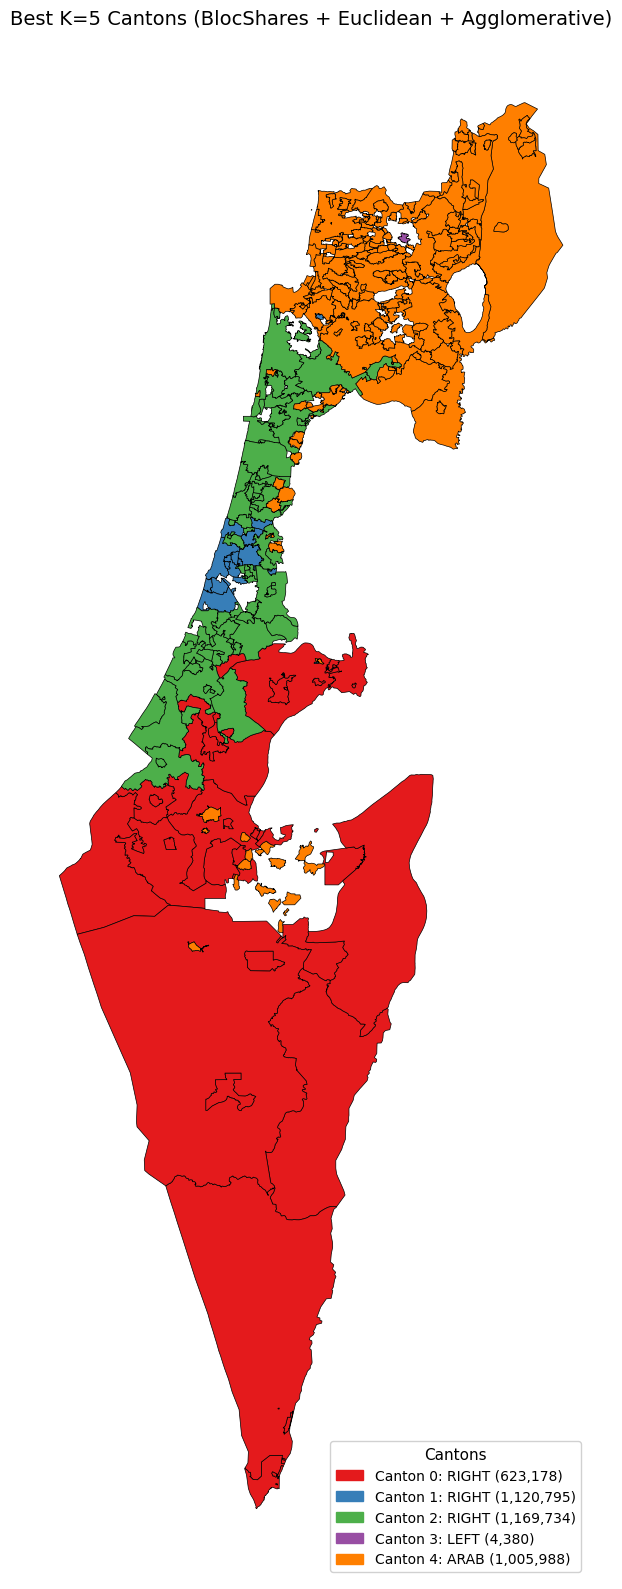

In [22]:
# Visualize best K=5 cantons on map
geo = gpd.read_file(DATA_PROCESSED / 'municipalities_dissolved.geojson')

fig = plot_cantons(ca, geo, profiles=profiles_k5,
                   title='Best K=5 Cantons (BlocShares + Euclidean + Agglomerative)')
plt.show()

## 9. Canton Labeling

Assign meaningful labels to each canton based on dominant political bloc and geographic location.

In [24]:
# Canton labeling based on dominant bloc + geographic center of mass
geo = gpd.read_file(DATA_PROCESSED / 'municipalities_dissolved.geojson')
geo_centroids = geo.set_index('MUN_HEB').geometry.centroid

# Compute geographic center of mass for each canton (weighted by population)
canton_labels = {}
for cid in sorted(ca.canton_ids):
    members = ca.get_members(cid)
    profile = profiles_k5[profiles_k5['canton'] == cid].iloc[0]
    dominant = profile['dominant_bloc'].upper()
    total_voters = profile['total_voters']
    
    # Compute weighted centroid (latitude)
    lats = []
    w_sum = 0
    for m in members:
        if m in geo_centroids.index:
            lat = geo_centroids.loc[m].y
            w = weights.get(m, 1)
            lats.append(lat * w)
            w_sum += w
    
    if w_sum > 0:
        avg_lat = sum(lats) / w_sum
    else:
        avg_lat = 31.5
    
    # Assign geographic descriptor based on latitude
    if avg_lat > 32.5:
        geo_desc = "North"
    elif avg_lat > 31.8:
        geo_desc = "Center"
    else:
        geo_desc = "South"
    
    # Build label
    label = f"{dominant} {geo_desc}"
    canton_labels[cid] = label

print("CANTON LABELS")
print("=" * 80)
for cid in sorted(canton_labels):
    label = canton_labels[cid]
    profile = profiles_k5[profiles_k5['canton'] == cid].iloc[0]
    members = ca.get_members(cid)
    top5 = sorted(members, key=lambda m: weights.get(m, 0), reverse=True)[:5]
    print(f"  Canton {cid}: {label}")
    print(f"    Municipalities: {len(members)}, Voters: {int(profile['total_voters']):,}")
    print(f"    Top cities: {', '.join(top5)}")
    print()

# Save labeled cantons
labeled_df = ca.to_dataframe()
labeled_df['label'] = labeled_df['canton'].map(canton_labels)
labeled_df.to_csv(DATA_PROCESSED / 'cantons_labeled.csv', index=False, encoding='utf-8')
print(f"Saved cantons_labeled.csv ({len(labeled_df)} municipalities)")

CANTON LABELS
  Canton 0: RIGHT South
    Municipalities: 27, Voters: 623,178
    Top cities: ירושלים, באר שבע, בית שמש, קרית גת, מטה יהודה

  Canton 1: RIGHT Center
    Municipalities: 18, Voters: 1,120,795
    Top cities: תל אביב -יפו, ראשון לציון, פתח תקווה, חולון, רמת גן

  Canton 2: RIGHT Center
    Municipalities: 62, Voters: 1,169,734
    Top cities: אשדוד, נתניה, רחובות, אשקלון, מודיעין-מכבים-רעות

  Canton 3: LEFT North
    Municipalities: 1, Voters: 4,380
    Top cities: בית ג'ן

  Canton 4: ARAB North
    Municipalities: 121, Voters: 1,005,988
    Top cities: חיפה, נהריה, קרית אתא, נצרת, קרית מוצקין

Saved cantons_labeled.csv (229 municipalities)


## 10. Comparison to Administrative Districts

Compare our politically-derived cantons to Israel's official administrative districts (machoz) using the CBS locality data.

In [26]:
# Build municipality-to-district mapping from CBS data
cbs = pd.read_excel(DATA_PROCESSED.parent / 'raw' / 'localities_bycode.xlsx')

# Get unique localities with their districts
# The CBS file has locality-level data; we need municipality-level
from src.data.loader import load_cbs_localities, build_locality_to_municipality_mapping

cbs_data = load_cbs_localities()
loc_to_muni = build_locality_to_municipality_mapping(cbs_data)

# Build municipality → district mapping
# CBS districts: ירושלים, הצפון, חיפה, המרכז, תל אביב, הדרום, יו"ש
muni_to_district = {}
for _, row in cbs.iterrows():
    locality_name = str(row.get('שם יישוב', '')).strip()
    district_name = str(row.get('שם מחוז', '')).strip()
    
    # Map locality to municipality
    muni = loc_to_muni.get(locality_name, locality_name)
    if muni and district_name and district_name != 'nan':
        muni_to_district[muni] = district_name

# Filter to our 229 municipalities
canton_munis = set(ca.assignments.keys())
matched_districts = {m: d for m, d in muni_to_district.items() if m in canton_munis}
print(f"Municipalities with district info: {len(matched_districts)} / {len(canton_munis)}")
print(f"Districts found: {sorted(set(matched_districts.values()))}")

Municipalities with district info: 149 / 229
Districts found: ['הדרום', 'המרכז', 'הצפון', 'חיפה', 'ירושלים', 'תל אביב']


In [27]:
# Cross-tabulation: Canton × Administrative District
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

# Create aligned label arrays
common_munis = sorted(set(ca.assignments.keys()) & set(matched_districts.keys()))
canton_labels_arr = [ca.assignments[m] for m in common_munis]
district_labels_arr = [matched_districts[m] for m in common_munis]

# Compute ARI and NMI between canton assignment and administrative districts
ari = adjusted_rand_score(district_labels_arr, canton_labels_arr)
nmi = normalized_mutual_info_score(district_labels_arr, canton_labels_arr)

print(f"Overlap between Cantons (K=5) and Administrative Districts:")
print(f"  ARI: {ari:.3f}")
print(f"  NMI: {nmi:.3f}")
print()

# Cross-tabulation table
cross_df = pd.DataFrame({'municipality': common_munis,
                          'canton': canton_labels_arr,
                          'district': district_labels_arr})
cross_tab = pd.crosstab(cross_df['canton'], cross_df['district'], margins=True)
print("Cross-tabulation (Canton × District):")
print(cross_tab.to_string())

print()
print("Interpretation:")
if ari < 0.2:
    print("  Low ARI indicates cantons are POLITICALLY derived, not geographically.")
    print("  Political clustering cuts across administrative boundaries.")
elif ari < 0.5:
    print("  Moderate ARI suggests partial alignment with geographic districts,")
    print("  but political dimensions add distinctive groupings.")
else:
    print("  High ARI suggests strong alignment between political and administrative divisions.")

Overlap between Cantons (K=5) and Administrative Districts:
  ARI: 0.435
  NMI: 0.427

Cross-tabulation (Canton × District):
district  הדרום  המרכז  הצפון  חיפה  ירושלים  תל אביב  All
canton                                                    
0            13      0      0     0        3        0   16
1             0      7      0     1        0        8   16
2             4     20      3     6        0        2   35
3             0      0      1     0        0        0    1
4             4      7     59    10        1        0   81
All          21     34     63    17        4       10  149

Interpretation:
  Moderate ARI suggests partial alignment with geographic districts,
  but political dimensions add distinctive groupings.
